<a href="https://colab.research.google.com/github/Aman7747/Atri-AI-Submission/blob/main/fashion_mnist_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1
Download the Fashion-MNIST dataset and plot 1 sample image for each class as
shown in the grid below. Use "from keras. datasets import fashion_mnist" for getting
the Fashion MNIST dataset

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
import wandb



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


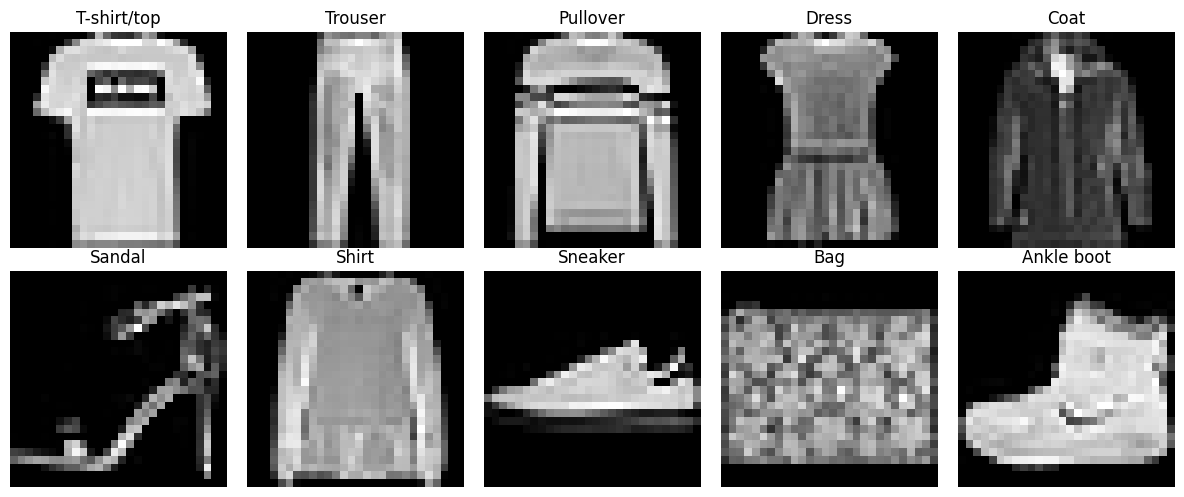

In [5]:
# plots for 1 sample image from each class

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
seen = set()

for img, label in zip(x_train, y_train):
    if label not in seen:
        ax = axes[label // 5, label % 5]
        ax.imshow(img, cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")
        seen.add(label)
    if len(seen) == 10:

        break

wandb.log({
    "Fashion_MNIST_Samples": [
        wandb.Image(
            axes[i // 5, i % 5].images[0].get_array(),
            caption=class_names[i]
        )
        for i in range(10)
    ]
})
plt.tight_layout()
plt.show()

##Question 2
Implement a feedforward neural network that takes images from the Fashion-MNIST
data as input and outputs a probability distribution over the 10 classes.

In [38]:
import numpy as np

# Activation Functions

def sigmoid(x):
    return 1/(1+np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()



In [39]:
# Weight Initialization

def init_weights(init_type, out_dim, in_dim):

    if init_type == "random":
        return np.random.randn(out_dim, in_dim) * 0.01

    elif init_type == "xavier":
        return np.random.randn(out_dim, in_dim) * np.sqrt(1/in_dim)





In [40]:
# Linear Forward

def linear_forward(h_prev, W, b):

    h_prev = h_prev.reshape(h_prev.shape[0], -1)

    z = np.dot(W, h_prev) + b

    cache = (h_prev, W, b)

    return z, cache

In [41]:

# Initialize Network

def init_network(X, hidden_layers, hidden_size, init_type):

    layers = [X.shape[0]]

    for _ in range(hidden_layers):
        layers.append(hidden_size)

    layers.append(10)

    np.random.seed(42)

    params = {}
    velocity = {}
    grads = {}

    L = len(layers)

    for l in range(1, L):

        params[f"W{l}"] = init_weights(
            init_type,
            layers[l],
            layers[l-1]
        )

        params[f"b{l}"] = np.zeros((layers[l], 1))

        velocity[f"W{l}"] = np.zeros((layers[l], layers[l-1]))
        velocity[f"b{l}"] = np.zeros((layers[l], 1))

        grads[f"dW{l}"] = np.zeros((layers[l], layers[l-1]))
        grads[f"db{l}"] = np.zeros((layers[l], 1))

    return params, velocity, grads

In [42]:
# Activation Forward

def act_forward(h_prev, W, b, act):

    z, linear_cache = linear_forward(h_prev, W, b)

    act_cache = z

    if act == "relu":
        h = relu(z)

    elif act == "sigmoid":
        h = sigmoid(z)

    elif act == "tanh":
        h = tanh(z)

    elif act == "softmax":
        h = softmax(z)

    return h, act_cache, linear_cache


In [43]:
# Full Forward Propagation

def forward_prop(X, params, act):

    h = X

    L = len(params)//2

    a_cache = []
    h_cache = [h]

    for l in range(1, L):

        h_prev = h

        h, a, lin = act_forward(
            h_prev,
            params[f"W{l}"],
            params[f"b{l}"],
            act
        )

        a_cache.append(a)
        h_cache.append(h)

    y_hat, a, lin = act_forward(
        h,
        params[f"W{L}"],
        params[f"b{L}"],
        act="softmax"
    )

    a_cache.append(a)
    h_cache.append(y_hat)

    return y_hat, h_cache, a_cache



# Question 3

Implement the backpropagation algorithm with support for the following optimisation functions:

- SGD  
- Momentum-based Gradient Descent  
- Nesterov Accelerated Gradient Descent
- RMSProp  
- Adam  
- Nadam

In [44]:
# One Hot Encoding

def one_hot_encoding(y, num_classes):

    vec = []

    for i in range(num_classes):

        if i == y:
            vec.append(1)

        else:
            vec.append(0)

    return np.asarray(vec)

In [45]:
# Derivative of Activation Functions

def activation_grad(z, act):

    if act == "relu":

        z[z <= 0] = 0
        z[z > 0] = 1

        return z

    elif act == "sigmoid":

        return sigmoid(z) * (1 - sigmoid(z))

    elif act == "tanh":

        return 1 - (tanh(z))**2


In [46]:

# Backpropagation

def backward_prop(h_cache, a_cache, params, y_hat, y, act, weight_decay, loss):

    y_onehot = []

    L = len(params)//2

    samples = y_hat.shape[1]
    classes = y_hat.shape[0]

    for i in range(samples):

        y_onehot.append(one_hot_encoding(y[i], classes))
    y_onehot = np.reshape(y_onehot,(classes, samples))

    # Loss derivative
    if loss == "cross_entropy":

        da = -(y_onehot - y_hat)

    elif loss == "mse":

        da = (y_hat - y_onehot)

    grads = {}

    # Backward loop
    for l in reversed(range(1, L+1)):

        dW = np.matmul( da, np.transpose(h_cache[l-1])) + 2 * weight_decay * params[f"W{l}"]
        db = da

        if l != 1:
            dh = np.dot(params[f"W{l}"].T, da)
            da = np.multiply( dh, activation_grad(a_cache[l-2], act))

        grads[f"dW{l}"] = dW
        grads[f"db{l}"] = db

    return grads

In [47]:
# SGD Optimizer

def sgd(params, grads, lr, L):

    for l in range(L):

        params[f"W{l+1}"] -= lr * grads[f"dW{l+1}"]
        params[f"b{l+1}"] -= lr * grads[f"db{l+1}"]

    return params

In [48]:
# Momentum Gradient Descent

def momentum(params, grads, lr, gamma, velocity, L):

    for l in range(L):

        velocity['W' + str(l+1)] = gamma * velocity['W' + str(l+1)] + lr * grads['dW' + str(l+1)]
        velocity['b' + str(l+1)] = gamma * velocity['b' + str(l+1)] + lr * grads['db' + str(l+1)]

        params['W' + str(l+1)] = params['W' + str(l+1)] - velocity['W' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - velocity['b' + str(l+1)]

    return params, velocity

In [49]:
# Nesterov Accelerated Gradient

def nestrov(params, lr, gamma, velocity, L):

    temp_params = {}

    for l in range(L):

        velocity['W' + str(l+1)] = gamma * velocity['W' + str(l+1)]
        velocity['b' + str(l+1)] = gamma * velocity['b' + str(l+1)]

        temp_params['W' + str(l+1)] = params['W' + str(l+1)] - velocity['W' + str(l+1)]
        temp_params['b' + str(l+1)] = params['b' + str(l+1)] - velocity['b' + str(l+1)]

    return temp_params, velocity

In [50]:
# RMSProp Optimizer

def rmsprop(params, lr, velocity, beta, eps, grads, L):

    for l in range(L):

        velocity['W' + str(l+1)] = beta * velocity['W' + str(l+1)] + (1-beta) * grads['dW' + str(l+1)]**2
        velocity['b' + str(l+1)] = beta * velocity['b' + str(l+1)] + (1-beta) * grads['db' + str(l+1)]**2

        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/np.sqrt(velocity['W' + str(l+1)] + eps)) * grads['dW' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/np.sqrt(velocity['b' + str(l+1)] + eps)) * grads['db' + str(l+1)]

    return params, velocity

In [51]:
# Adam Optimizer

def adam(params, lr, beta1, beta2, momentum, variance, eps, grads, L, t):

    import math

    m_hat = momentum.copy()

    v_hat = variance.copy()

    for l in range(L):

        momentum['W' + str(l+1)] = beta1 * momentum['W' + str(l+1)] + (1-beta1) * grads['dW' + str(l+1)]
        momentum['b' + str(l+1)] = beta1 * momentum['b' + str(l+1)] + (1-beta1) * grads['db' + str(l+1)]
        variance['W' + str(l+1)] = beta2 * variance['W' + str(l+1)] + (1-beta2) * grads['dW' + str(l+1)]**2
        variance['b' + str(l+1)] = beta2 * variance['b' + str(l+1)] + (1-beta2) * grads['db' + str(l+1)]**2

        m_hat['W' + str(l+1)] = momentum['W' + str(l+1)] / (1 - math.pow(beta1, t+1))
        m_hat['b' + str(l+1)] = momentum['b' + str(l+1)] / (1 - math.pow(beta1, t+1))
        v_hat['W' + str(l+1)] = variance['W' + str(l+1)] / (1 - math.pow(beta2, t+1))
        v_hat['b' + str(l+1)] = variance['b' + str(l+1)] / (1 - math.pow(beta2, t+1))

        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/(np.sqrt(v_hat['W' + str(l+1)] + eps))) * m_hat['W' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/(np.sqrt(v_hat['b' + str(l+1)] + eps))) * m_hat['b' + str(l+1)]

    return params, momentum, variance

In [52]:
# Nadam Optimizer

def nadam(params, lr, beta1, beta2, momentum, variance, eps, grads, L, t):

    import math

    m_hat = momentum.copy()

    v_hat = variance.copy()

    for l in range(L):

        momentum['W' + str(l+1)] = beta1 * momentum['W' + str(l+1)] + (1-beta1) * grads['dW' + str(l+1)]
        momentum['b' + str(l+1)] = beta1 * momentum['b' + str(l+1)] + (1-beta1) * grads['db' + str(l+1)]
        variance['W' + str(l+1)] = beta2 * variance['W' + str(l+1)] + (1-beta2) * grads['dW' + str(l+1)]**2
        variance['b' + str(l+1)] = beta2 * variance['b' + str(l+1)] + (1-beta2) * grads['db' + str(l+1)]**2

        m_hat['W' + str(l+1)] = momentum['W' + str(l+1)] / (1 - math.pow(beta1, t+1))
        m_hat['b' + str(l+1)] = momentum['b' + str(l+1)] / (1 - math.pow(beta1, t+1))
        v_hat['W' + str(l+1)] = variance['W' + str(l+1)] / (1 - math.pow(beta2, t+1))
        v_hat['b' + str(l+1)] = variance['b' + str(l+1)] / (1 - math.pow(beta2, t+1))

        nesterov_w = beta1 * m_hat['W' + str(l+1)] + ((1-beta1) * grads['dW' + str(l+1)]) / (1 - math.pow(beta1, t+1))
        nesterov_b = beta1 * m_hat['b' + str(l+1)] + ((1-beta1) * grads['db' + str(l+1)]) / (1 - math.pow(beta1, t+1))
        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/(np.sqrt(v_hat['W' + str(l+1)] + eps))) * nesterov_w
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/(np.sqrt(v_hat['b' + str(l+1)] + eps))) * nesterov_b

    return params, momentum, variance

# Question 4

Use the sweep functionality provided by WandB to find the best values for the hyperparameters listed below.

Use the standard train/test split of Fashion-MNIST:

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

Keep 10% of the training data aside as validation data for this hyperparameter search.

Here are some suggestions for different values to try for hyperparameters. As you can quickly see, this leads to an exponential number of combinations. Hence, WandB Sweeps are used with random search strategy for efficient hyperparameter tuning.

The following hyperparameters are explored:

- Number of epochs: 5, 10
- Number of hidden layers: 3, 4, 5
- Size of every hidden layer: 32, 64, 128
- Weight decay (L2 regularization): 0, 0.0005, 0.5
- Learning rate: 1e-3, 1e-4
- Optimizer: sgd, momentum, nestrov, rmsprop, adam, nadam
- Batch size: 16, 32, 64
- Weight initialization: random, xavier
- Activation functions: sigmoid, tanh, relu

Random search strategy is chosen because the hyperparameter space is very large, and random search explores diverse configurations more efficiently compared to exhaustive grid search.

In [53]:
# ==========================================
# SWEEP CONFIGURATION
# ==========================================

sweep_config = {

    "method": "grid",

    "metric": {

        "name": "validation_accuracy",

        "goal": "maximize"
    },

    "parameters": {

        "epochs": {

            "values": [10]
        },

        "hidden_layers": {

            "values": [4]
        },

        "hidden_size": {

            "values": [128]
        },

        "learning_rate": {

            "values": [1e-3]
        },

        "weight_decay": {

            "values": [0]
        },

        "batch_size": {

            "values": [16]
        },

        "weight_init": {

            "values": ["xavier"]
        },

        "activation": {

            "values": ["relu"]
        },

        "optimizer": {

            "values": [

                "adam",
                "nadam",
                "nestrov"
            ]
        }
    }
}





In [54]:

# TRAIN FUNCTION


import math
import numpy as np
import wandb

from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split


# LOAD DATA


(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = np.reshape(X_train, (X_train.shape[0], 784)) / 255.0
X_test = np.reshape(X_test, (X_test.shape[0], 784)) / 255.0


# Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)


# Smaller subset for faster sweeps
X_train = X_train[:12000]
y_train = y_train[:12000]

X_val = X_val[:2000]
y_val = y_val[:2000]


# Transpose
X_train = X_train.T
X_val = X_val.T
X_test = X_test.T




# TRAIN FUNCTION


def train():

    wandb.init()

    config = wandb.config



    # CONFIG PARAMETERS


    opt = config.optimizer

    bs = config.batch_size

    size_hidden = config.hidden_size

    activation = config.activation

    learning_rate = config.learning_rate

    weight_decay = config.weight_decay

    max_epoch = config.epochs

    initializer = config.weight_init

    num_hidden = config.hidden_layers

    loss_func = "cross_entropy"




    # WANDB RUN NAME


    wandb.run.name = (
        f"hl{num_hidden}"
        f"_hs{size_hidden}"
        f"_bs{bs}"
        f"_ac{activation}"
        f"_opt{opt}"
    )




    # FIXED PARAMETERS


    beta1 = 0.9

    beta2 = 0.999

    gamma = 0.9

    eps = 1e-8

    L = num_hidden + 1




    # INITIALIZE NETWORK

    params, velocity, grads_init = init_network(
        X_train,
        num_hidden,
        size_hidden,
        initializer
    )

    variance = velocity.copy()

    num_train = X_train.shape[1]

    num_val = X_val.shape[1]

    best_val_acc = 0




    # TRAINING LOOP


    for epoch in range(max_epoch):

        loss = 0

        correct = 0

        grads = grads_init



        # MINI BATCH TRAINING


        for j in range(num_train):

            x = np.reshape(X_train[:, j], (-1, 1))


            # Forward Propagation
            y_hat, h_cache, a_cache = forward_prop(
                x,
                params,
                activation
            )


            # Training Accuracy
            if y_train[j] == np.argmax(y_hat):

                correct += 1



            # Nesterov Look Ahead
            if (j + 1) % bs == 0:

                if opt == "nestrov":

                    params, velocity = nestrov(
                        params,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



            # Backpropagation
            grad = backward_prop(
                h_cache,
                a_cache,
                params,
                y_hat,
                [y_train[j]],
                activation,
                weight_decay,
                loss_func
            )



            # Accumulate Gradients
            for l in range(L):

                grads['dW' + str(l+1)] += grad['dW' + str(l+1)]

                grads['db' + str(l+1)] += grad['db' + str(l+1)]




            # UPDATE PARAMETERS


            if (j + 1) % bs == 0:

                for l in range(L):

                    grads['dW' + str(l+1)] /= bs

                    grads['db' + str(l+1)] /= bs



                # SGD
                if opt == "sgd":

                    params = sgd(
                        params,
                        grads,
                        learning_rate,
                        L
                    )



                # MOMENTUM
                elif opt == "momentum":

                    params, velocity = momentum(
                        params,
                        grads,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



                # NESTEROV
                elif opt == "nestrov":

                    params, velocity = momentum(
                        params,
                        grads,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



                # RMSPROP
                elif opt == "rmsprop":

                    params, velocity = rmsprop(
                        params,
                        learning_rate,
                        velocity,
                        beta1,
                        eps,
                        grads,
                        L
                    )



                # ADAM
                elif opt == "adam":

                    params, velocity, variance = adam(
                        params,
                        learning_rate,
                        beta1,
                        beta2,
                        velocity,
                        variance,
                        eps,
                        grads,
                        L,
                        epoch + 1
                    )



                # NADAM
                elif opt == "nadam":

                    params, velocity, variance = nadam(
                        params,
                        learning_rate,
                        beta1,
                        beta2,
                        velocity,
                        variance,
                        eps,
                        grads,
                        L,
                        epoch + 1
                    )



            # Cross Entropy Loss
            loss += -(
                1 / num_train
            ) * math.log(y_hat[y_train[j]][0])



        # VALIDATION


        y_pred_val, _, _ = forward_prop(
            X_val,
            params,
            activation
        )



        val_correct = np.sum(
            np.argmax(y_pred_val, axis=0) == y_val
        )



        train_accuracy = 100 * correct / num_train

        val_accuracy = 100 * val_correct / num_val



        # Best Accuracy
        if val_accuracy > best_val_acc:

            best_val_acc = val_accuracy



        # PRINT RESULTS


        print(
            "Epoch:",
            epoch + 1,
            "Train Acc:",
            round(train_accuracy, 2),
            "Val Acc:",
            round(val_accuracy, 2)
        )




        # WANDB LOGGING


        wandb.log({

            "epoch": epoch + 1,

            "train_accuracy": train_accuracy,

            "validation_accuracy": val_accuracy,

            "loss": loss,

            "optimizer": opt,

            "hidden_layers": num_hidden,

            "hidden_size": size_hidden,

            "batch_size": bs,

            "activation": activation,

            "learning_rate": learning_rate,

            "weight_decay": weight_decay

        })



        # EARLY STOPPING


        if epoch >= 2 and val_accuracy < 80:

            print(
                "Stopping early because validation accuracy is below 80%"
            )

            break




    # FINAL BEST ACCURACY


    print("\nBest Validation Accuracy:", best_val_acc)




    # TEST EVALUATION


    y_pred_test, _, _ = forward_prop(
        X_test,
        params,
        activation
    )



    # TEST ACCURACY


    test_predictions = np.argmax(
        y_pred_test,
        axis=0
    )

    test_correct = np.sum(
        test_predictions == y_test
    )

    test_accuracy = (
        100 * test_correct / X_test.shape[1]
    )



    # PRINT RESULTS


    print("Test Accuracy:",
          round(test_accuracy, 2))



    # LOG TO WANDB


    wandb.log({

        "test_accuracy": test_accuracy,



    })









In [55]:
# START SWEEP

wandb.login()


sweep_id = wandb.sweep(

    sweep_config,

    project="fashion_mnist_assignment"
)


wandb.agent(

    sweep_id,

    function=train,

    count=20
)

Create sweep with ID: o2s1pisy
Sweep URL: https://wandb.ai/zda24m013-iit-madras-zanzibar/fashion_mnist_assignment/sweeps/o2s1pisy


wandb: Agent Starting Run: nl6m37l1 with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_layers: 4
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	optimizer: adam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Ctrl + C detected. Stopping sweep.


In [67]:

# QUESTION 7
# CREATIVE CONFUSION MATRIX


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix




# CLASS LABELS


IMG_LABELS = [

    "T-shirt",

    "Trouser",

    "Pullover",

    "Dress",

    "Coat",

    "Sandal",

    "Shirt",

    "Sneaker",

    "Bag",

    "Ankle Boot"
]



# ==========================================
# CONFUSION MATRIX FUNCTION
# ==========================================

def plot_confusion_matrix(
    params,
    X_test,
    y_test,
    activation
):


    # ======================================
    # PREDICTIONS
    # ======================================

    y_pred, _, _ = forward_prop(
        X_test,
        params,
        activation
    )


    predicted_labels = np.argmax(
        y_pred,
        axis=0
    )



    # ======================================
    # CONFUSION MATRIX
    # ======================================

    cm = confusion_matrix(
        y_test,
        predicted_labels
    )



    # ======================================
    # DATAFRAME
    # ======================================

    df_cm = pd.DataFrame(

        cm,

        index=IMG_LABELS,

        columns=IMG_LABELS
    )



    # ======================================
    # PLOT STYLE
    # ======================================

    plt.figure(figsize=(14, 12))

    sns.set_style("whitegrid")



    # ======================================
    # HEATMAP
    # ======================================

    heatmap = sns.heatmap(

        df_cm,

        annot=True,

        fmt="d",

        linewidths=1.5,

        linecolor='black',

        cmap="rocket_r",

        cbar=True,

        square=True,

        annot_kws={

            "size": 12,

            "weight": "bold"
        }
    )



    # ======================================
    # TITLES & LABELS
    # ======================================

    plt.title(

        "Fashion-MNIST Confusion Matrix\n"
        "Model: hl4_hs128_bs16_acrelu_optnadam",

        fontsize=20,

        weight='bold',

        pad=20
    )


    plt.xlabel(

        "Predicted Label",

        fontsize=16,

        weight='bold'
    )


    plt.ylabel(

        "True Label",

        fontsize=16,

        weight='bold'
    )



    # ======================================
    # ROTATION
    # ======================================

    plt.xticks(

        rotation=45,

        fontsize=12
    )

    plt.yticks(

        rotation=0,

        fontsize=12
    )




    # BORDER STYLE


    for _, spine in heatmap.spines.items():

        spine.set_visible(True)

        spine.set_linewidth(2)




    # WANDB LOGGING


    wandb.log({

        "Confusion_Matrix": wandb.Image(
            plt,
            caption="hl4_hs128_bs16_acrelu_optnadam"
        )
    })




    # SHOW PLOT


    plt.tight_layout()

    plt.show()




# CALL FUNCTION


plot_confusion_matrix(

    best_params,

    X_test,

    y_test,

    "relu"
)

TypeError: object of type 'NoneType' has no len()

In [68]:

# TRAIN BEST MODEL SEPARATELY


best_optimizer = "nadam"

best_hidden_layers = 4

best_hidden_size = 128

best_activation = "relu"

best_learning_rate = 0.001

best_weight_decay = 0

best_initializer = "xavier"

best_epochs = 10

best_batch_size = 16



# ==========================================
# INITIALIZE NETWORK
# ==========================================

params, velocity, grads_init = init_network(

    X_train,

    best_hidden_layers,

    best_hidden_size,

    best_initializer
)

variance = velocity.copy()

L = best_hidden_layers + 1

num_train = X_train.shape[1]




# TRAINING LOOP


for epoch in range(best_epochs):

    grads = grads_init

    correct = 0

    for j in range(num_train):

        x = np.reshape(X_train[:, j], (-1, 1))

        y_hat, h_cache, a_cache = forward_prop(

            x,

            params,

            best_activation
        )

        if y_train[j] == np.argmax(y_hat):

            correct += 1


        grad = backward_prop(

            h_cache,

            a_cache,

            params,

            y_hat,

            [y_train[j]],

            best_activation,

            best_weight_decay,

            "cross_entropy"
        )


        for l in range(L):

            grads['dW' + str(l+1)] += grad['dW' + str(l+1)]

            grads['db' + str(l+1)] += grad['db' + str(l+1)]


        if (j + 1) % best_batch_size == 0:

            for l in range(L):

                grads['dW' + str(l+1)] /= best_batch_size

                grads['db' + str(l+1)] /= best_batch_size


            params, velocity, variance = nadam(

                params,

                best_learning_rate,

                0.9,

                0.999,

                velocity,

                variance,

                1e-8,

                grads,

                L,

                epoch + 1
            )


    train_accuracy = 100 * correct / num_train

    print(
        "Epoch:",
        epoch + 1,
        "Train Accuracy:",
        round(train_accuracy, 2)
    )

Epoch: 1 Train Accuracy: 76.47
Epoch: 2 Train Accuracy: 84.23
Epoch: 3 Train Accuracy: 85.9
Epoch: 4 Train Accuracy: 86.98
Epoch: 5 Train Accuracy: 87.97
Epoch: 6 Train Accuracy: 88.75
Epoch: 7 Train Accuracy: 89.24
Epoch: 8 Train Accuracy: 89.59
Epoch: 9 Train Accuracy: 90.14
Epoch: 10 Train Accuracy: 90.54


Error: You must call wandb.init() before wandb.log()

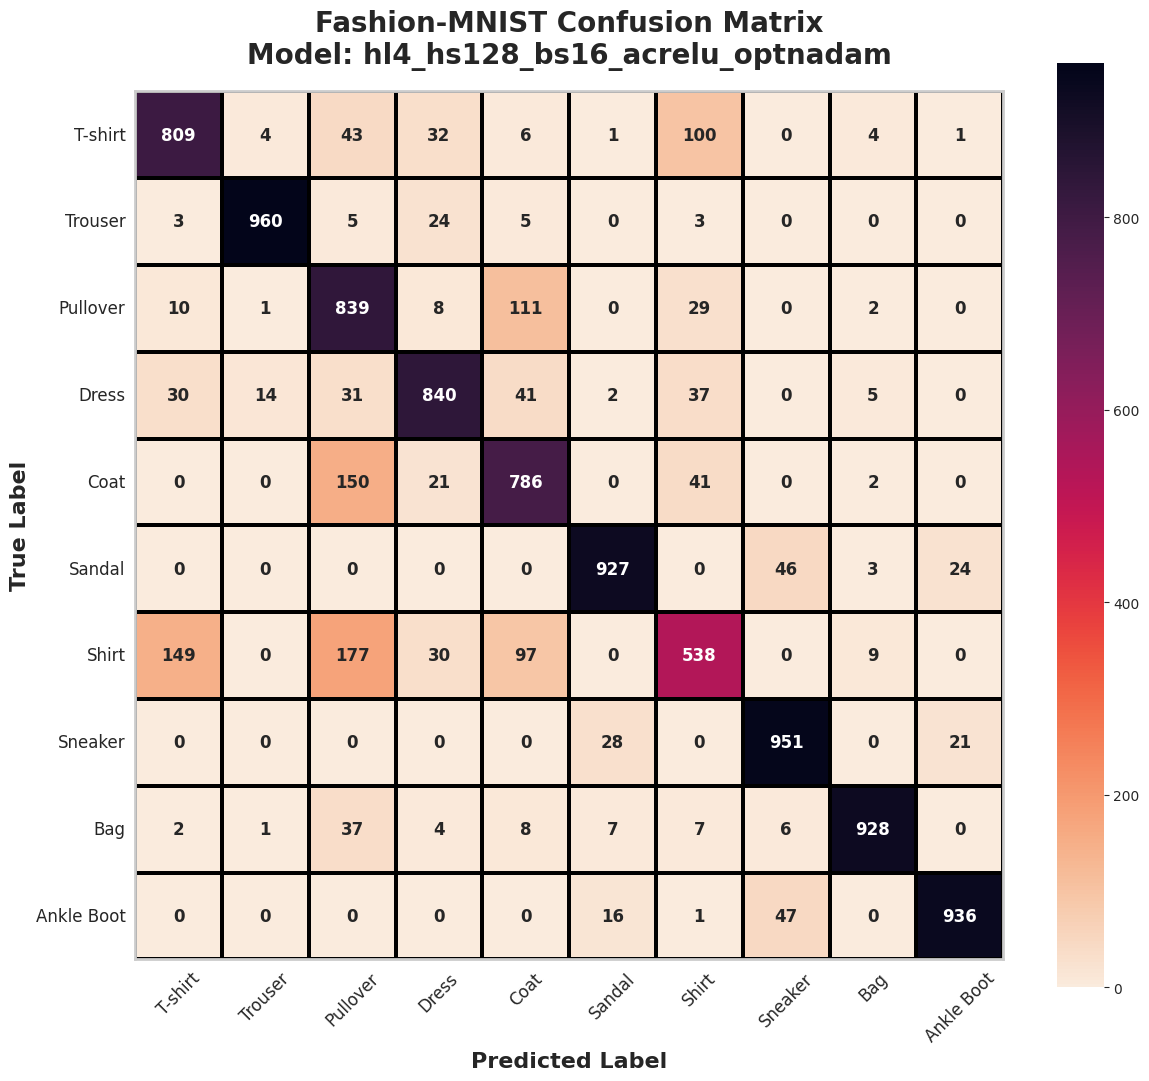

In [69]:
plot_confusion_matrix(

    params,

    X_test,

    y_test,

    "relu"
)

In [56]:

# SWEEP CONFIGURATION


sweep_config = {

    "method": "grid",

    "metric": {

        "name": "validation_accuracy",

        "goal": "maximize"
    },

    "parameters": {

        "epochs": {

            "values": [10]
        },

        "hidden_layers": {

            "values": [4]
        },

        "hidden_size": {

            "values": [128]
        },

        "learning_rate": {

            "values": [1e-3]
        },

        "weight_decay": {

            "values": [0]
        },

        "batch_size": {

            "values": [16]
        },

        "weight_init": {

            "values": ["xavier"]
        },

        "activation": {

            "values": ["relu"]
        },

        "optimizer": {

            "values": [

                "adam",
                "nadam",
                "nestrov"
            ]
        }
    }
}





In [57]:


# TRAIN FUNCTION


import math
import numpy as np
import wandb

from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split


# LOAD DATA


(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = np.reshape(X_train, (X_train.shape[0], 784)) / 255.0
X_test = np.reshape(X_test, (X_test.shape[0], 784)) / 255.0


# Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)


# Smaller subset for faster sweeps
X_train = X_train[:12000]
y_train = y_train[:12000]

X_val = X_val[:2000]
y_val = y_val[:2000]


# Transpose
X_train = X_train.T
X_val = X_val.T
X_test = X_test.T




# TRAIN FUNCTION


def train():

    wandb.init()

    config = wandb.config


    # CONFIG PARAMETERS


    opt = config.optimizer

    bs = config.batch_size

    size_hidden = config.hidden_size

    activation = config.activation

    learning_rate = config.learning_rate

    weight_decay = config.weight_decay

    max_epoch = config.epochs

    initializer = config.weight_init

    num_hidden = config.hidden_layers

    loss_func = "mse"




    # WANDB RUN NAME


    wandb.run.name = (
        f"hl{num_hidden}"
        f"_hs{size_hidden}"
        f"_bs{bs}"
        f"_ac{activation}"
        f"_opt{opt}"
    )




    # FIXED PARAMETERS


    beta1 = 0.9

    beta2 = 0.999

    gamma = 0.9

    eps = 1e-8

    L = num_hidden + 1




    # INITIALIZE NETWORK


    params, velocity, grads_init = init_network(
        X_train,
        num_hidden,
        size_hidden,
        initializer
    )

    variance = velocity.copy()

    num_train = X_train.shape[1]

    num_val = X_val.shape[1]

    best_val_acc = 0



    # TRAINING LOOP


    for epoch in range(max_epoch):

        loss = 0

        correct = 0

        grads = grads_init



        # MINI BATCH TRAINING


        for j in range(num_train):

            x = np.reshape(X_train[:, j], (-1, 1))


            # Forward Propagation
            y_hat, h_cache, a_cache = forward_prop(
                x,
                params,
                activation
            )


            # Training Accuracy
            if y_train[j] == np.argmax(y_hat):

                correct += 1



            # Nesterov Look Ahead
            if (j + 1) % bs == 0:

                if opt == "nestrov":

                    params, velocity = nestrov(
                        params,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



            # Backpropagation
            grad = backward_prop(
                h_cache,
                a_cache,
                params,
                y_hat,
                [y_train[j]],
                activation,
                weight_decay,
                loss_func
            )



            # Accumulate Gradients
            for l in range(L):

                grads['dW' + str(l+1)] += grad['dW' + str(l+1)]

                grads['db' + str(l+1)] += grad['db' + str(l+1)]



            # UPDATE PARAMETERS


            if (j + 1) % bs == 0:

                for l in range(L):

                    grads['dW' + str(l+1)] /= bs

                    grads['db' + str(l+1)] /= bs



                # SGD
                if opt == "sgd":

                    params = sgd(
                        params,
                        grads,
                        learning_rate,
                        L
                    )



                # MOMENTUM
                elif opt == "momentum":

                    params, velocity = momentum(
                        params,
                        grads,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



                # NESTEROV
                elif opt == "nestrov":

                    params, velocity = momentum(
                        params,
                        grads,
                        learning_rate,
                        gamma,
                        velocity,
                        L
                    )



                # RMSPROP
                elif opt == "rmsprop":

                    params, velocity = rmsprop(
                        params,
                        learning_rate,
                        velocity,
                        beta1,
                        eps,
                        grads,
                        L
                    )



                # ADAM
                elif opt == "adam":

                    params, velocity, variance = adam(
                        params,
                        learning_rate,
                        beta1,
                        beta2,
                        velocity,
                        variance,
                        eps,
                        grads,
                        L,
                        epoch + 1
                    )



                # NADAM
                elif opt == "nadam":

                    params, velocity, variance = nadam(
                        params,
                        learning_rate,
                        beta1,
                        beta2,
                        velocity,
                        variance,
                        eps,
                        grads,
                        L,
                        epoch + 1
                    )



            # Cross Entropy Loss
            loss += -(
                1 / num_train
            ) * math.log(y_hat[y_train[j]][0])




        # VALIDATION


        y_pred_val, _, _ = forward_prop(
            X_val,
            params,
            activation
        )



        val_correct = np.sum(
            np.argmax(y_pred_val, axis=0) == y_val
        )



        train_accuracy = 100 * correct / num_train

        val_accuracy = 100 * val_correct / num_val



        # Best Accuracy
        if val_accuracy > best_val_acc:

            best_val_acc = val_accuracy




        # PRINT RESULTS


        print(
            "Epoch:",
            epoch + 1,
            "Train Acc:",
            round(train_accuracy, 2),
            "Val Acc:",
            round(val_accuracy, 2)
        )



        # WANDB LOGGING


        wandb.log({

            "epoch": epoch + 1,

            "train_accuracy": train_accuracy,

            "validation_accuracy": val_accuracy,

            "loss": loss,

            "optimizer": opt,

            "hidden_layers": num_hidden,

            "hidden_size": size_hidden,

            "batch_size": bs,

            "activation": activation,

            "learning_rate": learning_rate,

            "weight_decay": weight_decay

        })



        # EARLY STOPPING


        if epoch >= 2 and val_accuracy < 80:

            print(
                "Stopping early because validation accuracy is below 80%"
            )

            break




    # FINAL BEST ACCURACY


    print("\nBest Validation Accuracy:", best_val_acc)






    # TEST EVALUATION


    y_pred_test, _, _ = forward_prop(
        X_test,
        params,
        activation
    )



    # TEST ACCURACY

    test_predictions = np.argmax(
        y_pred_test,
        axis=0
    )

    test_correct = np.sum(
        test_predictions == y_test
    )

    test_accuracy = (
        100 * test_correct / X_test.shape[1]
    )



    # PRINT RESULTS




    print("Test Accuracy:",
          round(test_accuracy, 2))




    # LOG TO WANDB


    wandb.log({

        "test_accuracy": test_accuracy,



    })



    wandb.finish()







In [58]:
# START SWEEP

wandb.login()


sweep_id = wandb.sweep(

    sweep_config,

    project="Fashion_mnist_mse"
)


wandb.agent(

    sweep_id,

    function=train,

    count=20
)

Create sweep with ID: 0bbxguzw
Sweep URL: https://wandb.ai/zda24m013-iit-madras-zanzibar/Fashion_mnist_mse/sweeps/0bbxguzw


wandb: Agent Starting Run: mp98rxl9 with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_layers: 4
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	optimizer: adam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch: 1 Train Acc: 75.28 Val Acc: 81.3
Epoch: 2 Train Acc: 84.22 Val Acc: 83.85
Epoch: 3 Train Acc: 85.84 Val Acc: 85.15
Epoch: 4 Train Acc: 87.1 Val Acc: 85.8
Epoch: 5 Train Acc: 87.79 Val Acc: 86.2
Epoch: 6 Train Acc: 88.54 Val Acc: 86.85
Epoch: 7 Train Acc: 89.06 Val Acc: 87.25
Epoch: 8 Train Acc: 89.55 Val Acc: 87.15
Epoch: 9 Train Acc: 89.87 Val Acc: 87.3
Epoch: 10 Train Acc: 90.34 Val Acc: 87.25

Best Validation Accuracy: 87.3
Test Accuracy: 85.69


batch_size,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
hidden_layers,▁▁▁▁▁▁▁▁▁▁
hidden_size,▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁
loss,█▄▃▃▂▂▂▁▁▁
test_accuracy,▁
train_accuracy,▁▅▆▆▇▇▇███
validation_accuracy,▁▄▅▆▇▇████
weight_decay,▁▁▁▁▁▁▁▁▁▁
activation,relu


wandb: Agent Starting Run: uemtdo6x with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_layers: 4
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

batch_size,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
hidden_layers,▁▁▁▁▁▁▁▁▁▁
hidden_size,▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁
loss,█▄▃▃▂▂▂▁▁▁
test_accuracy,▁
train_accuracy,▁▅▆▆▇▇▇███
validation_accuracy,▁▄▅▅▆▇▇▇██
weight_decay,▁▁▁▁▁▁▁▁▁▁
activation,relu


wandb: Agent Starting Run: 72n2m5as with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_layers: 4
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	optimizer: nestrov
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch: 1 Train Acc: 59.46 Val Acc: 71.75
Epoch: 2 Train Acc: 76.92 Val Acc: 78.25
Epoch: 3 Train Acc: 80.55 Val Acc: 81.05
Epoch: 4 Train Acc: 82.37 Val Acc: 82.35
Epoch: 5 Train Acc: 83.4 Val Acc: 82.9
Epoch: 6 Train Acc: 84.36 Val Acc: 83.65
Epoch: 7 Train Acc: 85.08 Val Acc: 84.1
Epoch: 8 Train Acc: 85.74 Val Acc: 84.6
Epoch: 9 Train Acc: 86.19 Val Acc: 84.85
Epoch: 10 Train Acc: 86.62 Val Acc: 85.2

Best Validation Accuracy: 85.2
Test Accuracy: 83.91


batch_size,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
hidden_layers,▁▁▁▁▁▁▁▁▁▁
hidden_size,▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁
loss,█▃▃▂▂▂▁▁▁▁
test_accuracy,▁
train_accuracy,▁▅▆▇▇▇████
validation_accuracy,▁▄▆▇▇▇▇███
weight_decay,▁▁▁▁▁▁▁▁▁▁
activation,relu


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [95]:

# LOAD MNIST DATASET


from keras.datasets import mnist
import numpy as np
import wandb

(trainX_2, trainy_2), (testX_2, testy_2) = mnist.load_data()

print('Train: X=%s, y=%s' % (trainX_2.shape, trainy_2.shape))
print('Test: X=%s, y=%s' % (testX_2.shape, testy_2.shape))

# NUMBER OF CLASSES


N_CLASSES_2 = np.unique(trainy_2).shape[0]


# SPLIT DATA


trainX_split_2, trainY_split_2, validX_split_2, validY_split_2 = train_validation_split(

    trainX_2,
    trainy_2,
    0.9

)


# TRANSFORM DATA


trainX_tr_2, trainY_tr_2 = transform_NN_IO(

    trainX_split_2,
    trainY_split_2,
    N_CLASSES_2

)

validX_tr_2, validY_tr_2 = transform_NN_IO(

    validX_split_2,
    validY_split_2,
    N_CLASSES_2

)

testX_tr_2, testY_tr_2 = transform_NN_IO(

    testX_2,
    testy_2,
    N_CLASSES_2

)

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


In [101]:

# TEST TOP 3 CONFIGS ON MNIST


best_configs = [

    {
        "optimizer": "adam",
        "batch_size": 16,
        "learning_rate": 1e-3,
        "epochs": 10,
        "hidden_layers": 4,
        "hidden_size": 128,
        "weight_init": "xavier",
        "activation": "relu",
        "weight_decay": 0
    },

    {
        "optimizer": "nadam",
        "batch_size": 16,
        "learning_rate": 1e-3,
        "epochs": 10,
        "hidden_layers": 4,
        "hidden_size": 128,
        "weight_init": "xavier",
        "activation": "relu",
        "weight_decay": 0
    },

    {
        "optimizer": "nestrov",
        "batch_size": 16,
        "learning_rate": 1e-3,
        "epochs": 10,
        "hidden_layers": 4,
        "hidden_size": 128,
        "weight_init": "xavier",
        "activation": "relu",
        "weight_decay": 0
    }

]



# REPLACE DATASET WITH MNIST


X_train = trainX_tr_2.T
X_val = validX_tr_2.T
X_test = testX_tr_2.T

y_train = np.argmax(trainY_tr_2, axis=1)
y_val = np.argmax(validY_tr_2, axis=1)
y_test = np.argmax(testY_tr_2, axis=1)



# RUN CONFIGURATIONS


for cfg in best_configs:

    wandb.init(

        project="MNIST_Top3_Configs",

        config=cfg,

        reinit=True

    )

    print("\n" + "="*60)
    print("Running Configuration:")
    print(cfg)
    print("="*60)

    network = train()


Running Configuration:
{'optimizer': 'adam', 'batch_size': 16, 'learning_rate': 0.001, 'epochs': 10, 'hidden_layers': 4, 'hidden_size': 128, 'weight_init': 'xavier', 'activation': 'relu', 'weight_decay': 0}


Epoch: 1 Train Acc: 81.76 Val Acc: 91.58
Epoch: 2 Train Acc: 93.98 Val Acc: 94.18
Epoch: 3 Train Acc: 95.79 Val Acc: 95.58
Epoch: 4 Train Acc: 96.73 Val Acc: 95.87
Epoch: 5 Train Acc: 97.37 Val Acc: 96.28
Epoch: 6 Train Acc: 97.89 Val Acc: 96.38
Epoch: 7 Train Acc: 98.31 Val Acc: 96.53
Epoch: 8 Train Acc: 98.55 Val Acc: 96.52
Epoch: 9 Train Acc: 98.81 Val Acc: 96.45
Epoch: 10 Train Acc: 99.01 Val Acc: 96.62

Best Validation Accuracy: 96.61666666666666
Test Accuracy: 96.54


batch_size,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
hidden_layers,▁▁▁▁▁▁▁▁▁▁
hidden_size,▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁
loss,█▃▂▂▂▁▁▁▁▁
test_accuracy,▁
train_accuracy,▁▆▇▇▇█████
validation_accuracy,▁▅▇▇██████
weight_decay,▁▁▁▁▁▁▁▁▁▁
activation,relu



Running Configuration:
{'optimizer': 'nadam', 'batch_size': 16, 'learning_rate': 0.001, 'epochs': 10, 'hidden_layers': 4, 'hidden_size': 128, 'weight_init': 'xavier', 'activation': 'relu', 'weight_decay': 0}


Epoch: 1 Train Acc: 81.76 Val Acc: 91.58
Epoch: 2 Train Acc: 93.98 Val Acc: 94.18
Epoch: 3 Train Acc: 95.79 Val Acc: 95.58
Epoch: 4 Train Acc: 96.73 Val Acc: 95.87
Epoch: 5 Train Acc: 97.37 Val Acc: 96.28
Epoch: 6 Train Acc: 97.89 Val Acc: 96.38
Epoch: 7 Train Acc: 98.31 Val Acc: 96.53
Epoch: 8 Train Acc: 98.55 Val Acc: 96.52
Epoch: 9 Train Acc: 98.81 Val Acc: 96.45
Epoch: 10 Train Acc: 99.01 Val Acc: 96.62

Best Validation Accuracy: 96.61666666666666
Test Accuracy: 96.54


...

Epoch: 1 Train Acc: 81.76 Val Acc: 91.58


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


Epoch: 2 Train Acc: 93.98 Val Acc: 94.18
Epoch: 3 Train Acc: 95.79 Val Acc: 95.58
Epoch: 4 Train Acc: 96.73 Val Acc: 95.87
Epoch: 5 Train Acc: 97.37 Val Acc: 96.28
Epoch: 6 Train Acc: 97.89 Val Acc: 96.38
Epoch: 7 Train Acc: 98.31 Val Acc: 96.53
Epoch: 8 Train Acc: 98.55 Val Acc: 96.52
Epoch: 9 Train Acc: 98.81 Val Acc: 96.45
Epoch: 10 Train Acc: 99.01 Val Acc: 96.62

Best Validation Accuracy: 96.61666666666666
Test Accuracy: 96.54


wandb: ERROR Control-C detected -- Run data was not synced


KeyboardInterrupt: 